In [19]:
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')  # Disable GPU temporarily to reconfigure
gpus = tf.config.list_physical_devices('GPU')


import pandas as pd
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import librosa
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
import numpy as np
from utils import apply_bandpass_filter, get_optimizer, get_class_weights, get_monitor, plot_confusion_matrix, plot_training_history, encode_labels, perform_patient_split, to_binary
import librosa

LOWCUT, HIGHCUT = 20, 500   
SEGMENT_EXTENSION_MS = 3

data = "../features-extraction/features-relative.csv"

df = pd.read_csv(data)

filtered_signals = {} 

df["file"] = df["file"].apply(lambda p: p.replace("\\", "/"))

for file_path in df["file"].unique():
    signal, fs = librosa.load(file_path)
    
    signal_filtered = apply_bandpass_filter(signal, fs)
    filtered_signals[file_path] = (signal_filtered, fs)

In [20]:

df["segment"] = None

for index, row in df.iterrows():
    file_path = row["file"]
    file_path = file_path.replace('\\', '/')
    signal_filtered, fs = filtered_signals[file_path]
    
    start_sample = row["Start"]
    end_sample = row["End"]
    
    start_sample = int(start_sample * fs)
    end_sample = int(end_sample * fs)
    extension_samples = int((SEGMENT_EXTENSION_MS / 1000) * fs)
    
    extended_start = max(0, start_sample - extension_samples)
    extended_end = min(len(signal_filtered), end_sample + extension_samples)
    
    segment = signal_filtered[extended_start:extended_end]
    df.at[index, "segment"] = segment


max_len = max(len(segment) for segment in df["segment"]) 

def pad_segment(segment, max_len):
    if len(segment) > max_len:
        return segment[:max_len]           
    else:
        return np.pad(segment, (0, max_len - len(segment)))  

features = []

segments = np.array([pad_segment(seg, max_len) for seg in df["segment"]])
features.append(segments)

X = np.stack(features, axis=-1)
print("X shape:", X.shape)  
print("Feature channels:", len(features))

def remap_label(label):
    label_lower = str(label).strip().lower()
    if label_lower in ['psw', 'fibrillation']:
        return 'positive'
    elif label_lower == "nan":
        return 'none'
    else:
        return str(label)  
    
def labels_to_string(label):
    label_lower = str(label).strip().lower()
    if label_lower == "nan":
        return 'none'
    else:
        return str(label)

df['Label_Remapped'] = df['Label'].apply(labels_to_string)

train_mask, test_mask, y_train, y_test = perform_patient_split(
    df,
    label_col="Label_Remapped"
)

X_train = X[train_mask]
X_test  = X[test_mask]

y_train, y_test, labels = encode_labels(y_train, y_test)



X shape: (4313, 979, 1)
Feature channels: 1


In [21]:


n_channels = X.shape[-1]

model = Sequential([
    Conv1D(64, 7, activation='relu', padding='same', input_shape=(max_len, n_channels)),  
    MaxPooling1D(2),
    Conv1D(128, 5, activation='relu', padding='same'),
    MaxPooling1D(2),
    Conv1D(256, 3, activation='relu', padding='same'),
    MaxPooling1D(2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

/home/joaquinm/EMG-Thesis/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
from tensorflow import keras
from sklearn.utils import shuffle

model.compile(
    optimizer=get_optimizer(),  
    loss='sparse_categorical_crossentropy',  
    metrics=["accuracy"]
)
history = model.fit(X_train, y_train,
                    epochs=100,
                    validation_split=0.1,
                    callbacks=[get_monitor()],
                    class_weight=get_class_weights(y_train))

Epoch 1/100


99/99 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.4817 - loss: 1.0596 - val_accuracy: 0.3037 - val_loss: 1.1240
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.6462 - loss: 0.9012 - val_accuracy: 0.7106 - val_loss: 1.0385
Epoch 3/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.7067 - loss: 0.8324 - val_accuracy: 0.8309 - val_loss: 0.7566
Epoch 4/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.7284 - loss: 0.7864 - val_accuracy: 0.8309 - val_loss: 0.7198
Epoch 5/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.7255 - loss: 0.7521 - val_accuracy: 0.7736 - val_loss: 0.7711
Epoch 6/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.7421 - loss: 0.7074 - val_accuracy: 0.8539 - val_loss: 0.5620
Epoch 7/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.7619 - loss: 0.6709 - val_accuracy: 0.7593 - val_loss: 0.7586
Epoch 8/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.7705 - loss: 0.6357 - val_accuracy: 0.8367 - val_

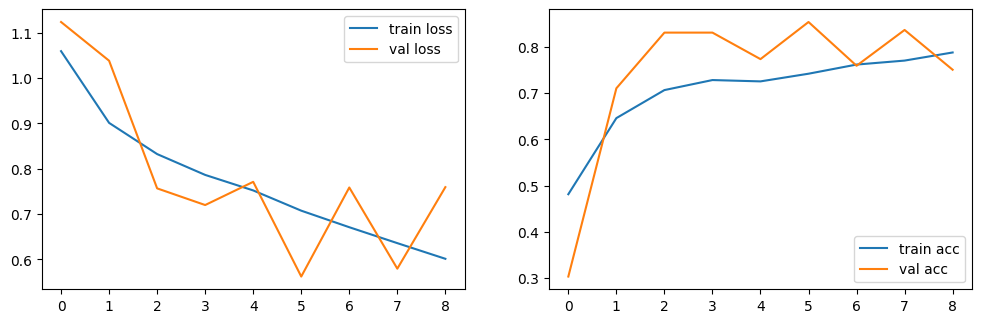

109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
['Fibrillation' 'Negative' 'PSW']


ValueError: Classification metrics can't handle a mix of unknown and multiclass targets

In [ ]:
plot_training_history(history)

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(labels)
plot_confusion_matrix(y_test, y_pred_classes, labels)

  1/109 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


<Figure size 600x500 with 0 Axes>

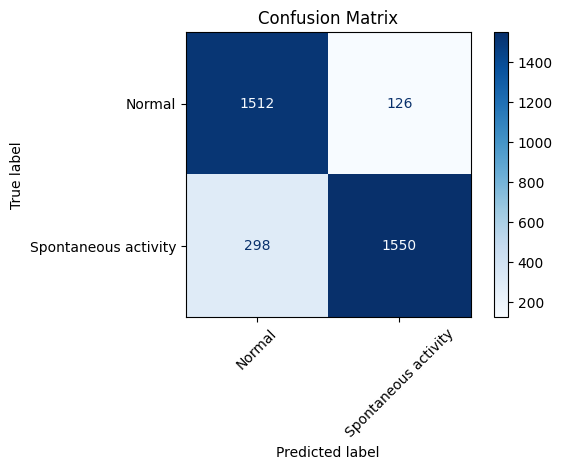


Classification Report:
                      precision    recall  f1-score   support

              Normal       0.84      0.92      0.88      1638
Spontaneous activity       0.92      0.84      0.88      1848

            accuracy                           0.88      3486
           macro avg       0.88      0.88      0.88      3486
        weighted avg       0.88      0.88      0.88      3486



In [ ]:
to_binary(y_test, X_test, model)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 979, 64)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 489, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 489, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 244, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 244, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 122, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 31232)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,997,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,439,307 (47.45 MB)

 Trainable params: 4,146,435 (15.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,292,872 (31.63 MB)